<a href="https://colab.research.google.com/github/GodishalaAshwith/DeepLearning/blob/main/DLClean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1

### 1. PyTorch Neural Network

In [ ]:
import torch
import torch.nn as nn

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

for _ in range(1000):
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(model(X).round())

tensor([[0.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)


### 2. TensorFlow Neural Network

In [ ]:
import tensorflow as tf

X = tf.constant([[0,0],[0,1],[1,0],[1,1]], dtype=tf.float32)
y = tf.constant([[0],[1],[1],[0]], dtype=tf.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(X, y, epochs=200, verbose=0)

print(model.predict(X).round())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0.]
 [1.]
 [1.]
 [0.]]


### 3. Keras (tf.keras)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# Ensure X and y are defined as tf.constant here, similar to the previous TensorFlow cell
X = tf.constant([[0,0],[0,1],[1,0],[1,1]], dtype=tf.float32)
y = tf.constant([[0],[1],[1],[0]], dtype=tf.float32)

model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(X, y, epochs=200, verbose=0)

print(model.predict(X).round())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.]
 [1.]
 [0.]
 [0.]]


### 4. Simple Perceptron

In [ ]:
# IMPLEMENT A SIMPLE PERCEPTRON (Coding a Neuron)

import numpy as np

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

class Neuron:
  def __init__(self, weights, bias):
    self.weights = weights
    self.bias = bias

  def feedforward(self, inputs):
    total = np.dot(self.weights, inputs) + self.bias
    return sigmoid(total)

weights = np.array([0, 1])
bias = 4

n = Neuron(weights, bias)

x = np.array([2, 3])
print(n.feedforward(x))


0.9990889488055994


# WEEK 2

### AND & OR

In [ ]:
import numpy as np

def step(x):
  return 1 if x>=0 else 0

class Perceptron:
  def __init__(self,weights,bias):
    self.weights = weights
    self.bias = bias

  def predict(self,input):
    total = np.dot(self.weights,input) + self.bias
    return step(total)

weights = np.array([1,1])
and_gate = Perceptron(weights,-1.5)
or_gate = Perceptron(weights, -0.5)

for x in [(0,0),(0,1),(1,0),(1,1)]:
  print(x, 'And ->' , and_gate.predict(np.array(x)))
  print(x, "Or ->", or_gate.predict(np.array(x)))

(0, 0) And -> 0
(0, 0) Or -> 0
(0, 1) And -> 0
(0, 1) Or -> 1
(1, 0) And -> 0
(1, 0) Or -> 1
(1, 1) And -> 1
(1, 1) Or -> 1


### XOR & XNOR using simple perceptron

In [ ]:
import numpy as np

def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = np.array(weights)
        self.bias = bias

    def predict(self, x):
        return step(np.dot(self.weights, x) + self.bias)

# Input data
X = np.array([[0,0],[0,1],[1,0],[1,1]])

# XOR and XNOR outputs
Y_xor = np.array([0,1,1,0])
Y_xnor = np.array([1,0,0,1])

# Try a perceptron
p = Perceptron(weights=[1, 1], bias=-1)

print("=== XOR Predictions ===")
correct = True
for x, y in zip(X, Y_xor):
    pred = p.predict(x)
    print(f"{x} -> Predicted: {pred}, Actual: {y}")
    if pred != y:
        correct = False
print("XOR correctly classified?", correct)

print("\n=== XNOR Predictions ===")
correct = True
for x, y in zip(X, Y_xnor):
    pred = p.predict(x)
    print(f"{x} -> Predicted: {pred}, Actual: {y}")
    if pred != y:
        correct = False
print("XNOR correctly classified?", correct)

=== XOR Predictions ===
[0 0] -> Predicted: 0, Actual: 0
[0 1] -> Predicted: 1, Actual: 1
[1 0] -> Predicted: 1, Actual: 1
[1 1] -> Predicted: 1, Actual: 0
XOR correctly classified? False

=== XNOR Predictions ===
[0 0] -> Predicted: 0, Actual: 1
[0 1] -> Predicted: 1, Actual: 0
[1 0] -> Predicted: 1, Actual: 0
[1 1] -> Predicted: 1, Actual: 1
XNOR correctly classified? False


### Implement the XOR and (¬XOR) logic operation using a multi-perceptron network

In [ ]:
import numpy as np
def step(x):
  return 1 if x>=0 else 0

class XoR:
  def __init__(self):
    self.w_or = self.w_and = np.array([1,1])
    self.b_or = -0.5; self.b_and = -1.5

    self.w_out = np.array([1,-2])
    self.b_out = -0.5

  def predict(self,x):
    h1 = step(np.dot(self.w_or,x)+self.b_or)
    h2 = step(np.dot(self.w_and,x)+self.b_and)

    output = step(np.dot(self.w_out,[h1,h2]) + self.b_out)
    return output

xor = XoR()
print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor.predict(np.array(x)))

#XNOR
import numpy as np
def step(x):
  return 1 if x>=0 else 0

class XNoR:
  def __init__(self):
    self.w_or = self.w_and = np.array([1,1])
    self.b_or = -0.5; self.b_and = -1.5

    self.w_out = np.array([1,-2])
    self.b_out = -0.5

  def predict(self,x):
    h1 = step(np.dot(self.w_or,x)+self.b_or)
    h2 = step(np.dot(self.w_and,x)+self.b_and)

    hidden = step(self.w_out[0]*h1 + self.w_out[1]*h2 + self.b_out)
    output = step(-hidden + 0.5)
    return output

xor = XNoR()
print("XNOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0
XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


### Thresholding logic used by perceptron is very harsh.

In [ ]:
def step(x):
  return 1 if x>=0 else 0

print(step(1))
print(step(0.00000001))
print(step(-0.00000001))

1
1
0


### Perceptron Learning Algorithm

In [ ]:
import numpy as np

# Dataset: [f1, f2, f3, f4] -> y
X = np.array([
    [1,1,0,0.85],
    [1,0,0,0.60],
    [0,1,1,0.90],
    [0,0,1,0.75],
    [0,0,0,0.40],
    [1,0,1,0.30],
    [0,1,0,0.45],
    [1,1,1,0.95]
])

y = np.array([1,1,1,1,0,0,0,1])

def step(z):
    return 1 if z >= 0 else 0

# i) MP Perceptron (No weights, No bias)
print("MP Perceptron")
def mp(x):
    return step(np.sum(x) - 1)   # simple threshold

for i in range(len(X)):
    print(X[i], "->", mp(X[i]), "| True:", y[i])

# ii) Perceptron (Weights only)
print("\nPerceptron (Weights only)")

def train_w(X, y, lr=0.1, epochs=10):
    w = np.zeros(X.shape[1])
    for _ in range(epochs):
        for i in range(len(X)):
            pred = step(np.dot(w, X[i]))
            w += lr * (y[i] - pred) * X[i]
    return w

w1 = train_w(X, y)
print("Weights:", w1)

# iii) Perceptron (Weights + Bias)
print("\nPerceptron (Weights + Bias)")

def train_wb(X, y, lr=0.1, epochs=10):
    w = np.zeros(X.shape[1])
    b = 0
    for _ in range(epochs):
        for i in range(len(X)):
            pred = step(np.dot(w, X[i]) + b)
            error = y[i] - pred
            w += lr * error * X[i]
            b += lr * error
    return w, b

w2, b2 = train_wb(X, y)
print("Weights:", w2)
print("Bias:", b2)

# iv) Testing
print("\nTest Sample")

test = np.array([1,1,0,0.80])

print("MP:", mp(test))
print("Weights only:", step(np.dot(w1, test)))
print("Weights + Bias:", step(np.dot(w2, test) + b2))

MP Perceptron
[1.   1.   0.   0.85] -> 1 | True: 1
[1.  0.  0.  0.6] -> 1 | True: 1
[0.  1.  1.  0.9] -> 1 | True: 1
[0.   0.   1.   0.75] -> 1 | True: 1
[0.  0.  0.  0.4] -> 0 | True: 0
[1.  0.  1.  0.3] -> 1 | True: 0
[0.   1.   0.   0.45] -> 1 | True: 0
[1.   1.   1.   0.95] -> 1 | True: 1

Perceptron (Weights only)
Weights: [ 0.1    0.1    0.1   -0.005]

Perceptron (Weights + Bias)
Weights: [0.1 0.1 0.  0.4]
Bias: -0.30000000000000004

Test Sample
MP: 1
Weights only: 1
Weights + Bias: 1


### Representation Power of a Network of Perceptrons

In [ ]:
import numpy as np
import itertools

def step(z):
    return 1 if z >= 0 else 0

# Hidden layer (one-hot)
def hidden(x):
    return np.array([
        step(-x[0] - x[1] + 0.5),   # (0,0)
        step(-x[0] + x[1] - 0.5),   # (0,1)
        step(x[0] - x[1] - 0.5),    # (1,0)
        step(x[0] + x[1] - 1.5)     # (1,1)
    ])

def mlp(x, truth):
    h = hidden(x)
    return step(np.dot(truth, h) - 0.5)

inputs = [(0,0),(0,1),(1,0),(1,1)]
functions = list(itertools.product([0,1], repeat=4))

print("Testing First 3 Boolean Functions:\n")

for idx, f in enumerate(functions[:3], 1):
    print(f"Function f{idx}: {f}")
    for x, y in zip(inputs, f):
        pred = mlp(x, f)
        print(f"Input {x} -> Output: {pred} (Expected: {y})")
    print("-"*30)

print("\nConclusion: MLP correctly represents all 16 Boolean functions.")

Testing First 3 Boolean Functions:

Function f1: (0, 0, 0, 0)
Input (0, 0) -> Output: 0 (Expected: 0)
Input (0, 1) -> Output: 0 (Expected: 0)
Input (1, 0) -> Output: 0 (Expected: 0)
Input (1, 1) -> Output: 0 (Expected: 0)
------------------------------
Function f2: (0, 0, 0, 1)
Input (0, 0) -> Output: 0 (Expected: 0)
Input (0, 1) -> Output: 0 (Expected: 0)
Input (1, 0) -> Output: 0 (Expected: 0)
Input (1, 1) -> Output: 1 (Expected: 1)
------------------------------
Function f3: (0, 0, 1, 0)
Input (0, 0) -> Output: 0 (Expected: 0)
Input (0, 1) -> Output: 0 (Expected: 0)
Input (1, 0) -> Output: 1 (Expected: 1)
Input (1, 1) -> Output: 0 (Expected: 0)
------------------------------

Conclusion: MLP correctly represents all 16 Boolean functions.


### Multi-Layer Perceptron (MLP) architecture

In [ ]:
import numpy as np
import itertools

def step(z):
    return 1 if z >= 0 else 0

# Correct hidden layer (one-hot encoding)
def hidden_layer(x):
    return np.array([
        step(-x[0] - x[1] + 0.5),   # (0,0)
        step(-x[0] + x[1] - 0.5),   # (0,1)
        step(x[0] - x[1] - 0.5),    # (1,0)
        step(x[0] + x[1] - 1.5)     # (1,1)
    ])

# MLP
def mlp(x, truth):
    h = hidden_layer(x)
    return step(np.dot(truth, h) - 0.5)

# Test all Boolean functions
inputs = [(0,0),(0,1),(1,0),(1,1)]
functions = list(itertools.product([0,1], repeat=4))

success = True

for i, f in enumerate(functions, 1):
    for x, y in zip(inputs, f):
        if mlp(x, f) != y:
            success = False
            print(f"Function f{i} failed")
            break

print("\nResult:", "All functions learned ✅" if success else "Some failed ❌")


Result: All functions learned ✅


### Three binary inputs?


In [ ]:
import numpy as np
import itertools

def step(z):
    return 1 if z >= 0 else 0

patterns = list(itertools.product([0,1], repeat=3))

# Hidden layer
def hidden(x):
    h = []
    for p in patterns:
        w = [1 if bit==1 else -1 for bit in p]
        b = -sum(p) + 0.5
        h.append(step(np.dot(w, x) + b))
    return np.array(h)

def mlp(x, truth):
    h = hidden(x)
    return step(np.dot(truth, h) - 0.5)

functions = list(itertools.product([0,1], repeat=8))

print("Testing First Boolean Function (3 inputs):\n")

f = functions[0]   # first function

for x, y in zip(patterns, f):
    pred = mlp(x, f)
    print(f"Input {x} -> Output: {pred} (Expected: {y})")

print("\nTotal Boolean functions for n=3:", 2**(2**3))
print("Conclusion: MLP can represent all 256 Boolean functions.")

Testing First Boolean Function (3 inputs):

Input (0, 0, 0) -> Output: 0 (Expected: 0)
Input (0, 0, 1) -> Output: 0 (Expected: 0)
Input (0, 1, 0) -> Output: 0 (Expected: 0)
Input (0, 1, 1) -> Output: 0 (Expected: 0)
Input (1, 0, 0) -> Output: 0 (Expected: 0)
Input (1, 0, 1) -> Output: 0 (Expected: 0)
Input (1, 1, 0) -> Output: 0 (Expected: 0)
Input (1, 1, 1) -> Output: 0 (Expected: 0)

Total Boolean functions for n=3: 256
Conclusion: MLP can represent all 256 Boolean functions.


# Week 3

### Implement an MLP by varying bias, weights, and learning rate

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rates: [0.0001, 0.001, 0.01, 0.1]
Loss: [0.6667677911962394, 0.29854230002248966, 0.4514716143283406, 0.7796914164232456]


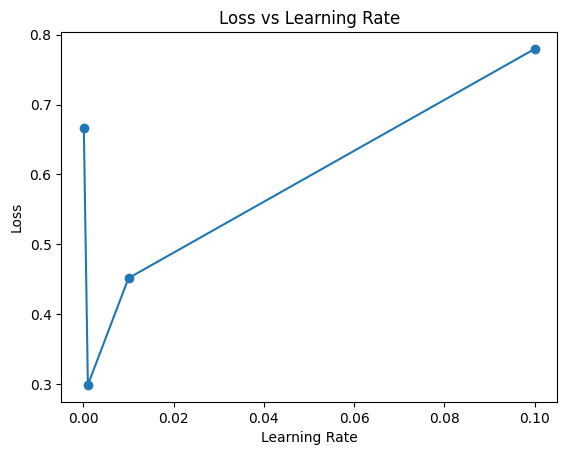

In [1]:
# 9
# Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values.
# Plot a graph showing the relationship between loss (error) and learning rate.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

learning_rates = [0.0001,0.001,0.01,0.1]
loss_values = []

for i, lr in enumerate(learning_rates):

    model = MLPClassifier(hidden_layer_sizes=(5,),
                          learning_rate_init=lr,
                          max_iter=500,
                          random_state= i+1 )

    model.fit(X_train,y_train)

    y_pred_prob = model.predict_proba(X_test)

    loss = log_loss(y_test,y_pred_prob)

    loss_values.append(loss)

print("Learning Rates:",learning_rates)
print("Loss:",loss_values)

plt.plot(learning_rates,loss_values,marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

# For the same learning rate, different initial weights and biases may lead to different convergence behaviors.
# Fixing the seed ensures fair comparison of learning rates, while varying initialization affects convergence speed and final loss.

### Implement an MLP using the Gradient Descent algorithm

Accuracy: 0.956140350877193


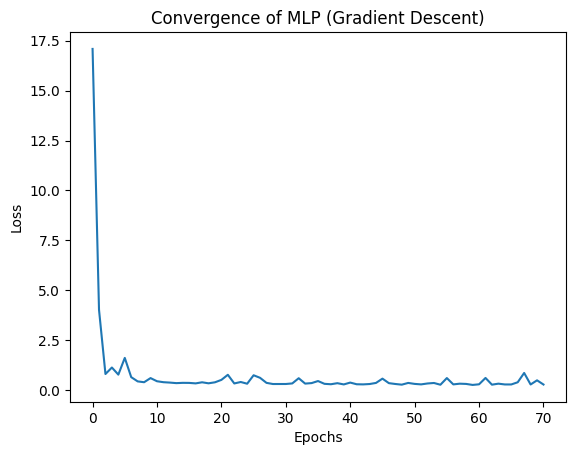

In [10]:
# 10
# Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42)

# MLP using Gradient Descent
model = MLPClassifier(hidden_layer_sizes=(5,),
                      solver='sgd',              # Gradient Descent
                      learning_rate_init=0.0001,
                      max_iter=500,
                      random_state=42)

model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, pred))

# Convergence (Loss Curve)
plt.plot(model.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence of MLP (Gradient Descent)")
plt.show()

### Perceptron on IRIS Dataset

In [14]:
# 11
# Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn.
# (explore all the parameters of Perceptron class).

from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42)

# SCALE FEATURES (VERY IMPORTANT)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

learning_rates = [0.0001, 0.001, 0.01, 0.1]

print("Learning Rate vs Accuracy\n")

for lr in learning_rates:
    model = Perceptron(max_iter=1000,
                       eta0=lr,
                       random_state=42)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    print(f"Learning Rate: {lr} → Accuracy: {acc:.4f}")

Learning Rate vs Accuracy

Learning Rate: 0.0001 → Accuracy: 0.9000
Learning Rate: 0.001 → Accuracy: 0.9000
Learning Rate: 0.01 → Accuracy: 0.9333
Learning Rate: 0.1 → Accuracy: 0.9333


### MLP on any dataset

In [2]:
# 12
# Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load data
data = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42)

learning_rates = [0.001, 0.01, 0.1]
iterations = [200, 500, 1000]

print("Exploring MLP Parameters\n")

for lr in learning_rates:
    for it in iterations:
        model = MLPClassifier(
            hidden_layer_sizes=(20,10),
            learning_rate_init=lr,
            max_iter=it,
            random_state=42
        )

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)
        print(f"LR: {lr}, Iter: {it} → Accuracy: {acc:.4f}")

Exploring MLP Parameters



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.001, Iter: 200 → Accuracy: 0.6944


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.001, Iter: 500 → Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


LR: 0.001, Iter: 1000 → Accuracy: 1.0000
LR: 0.01, Iter: 200 → Accuracy: 0.5556
LR: 0.01, Iter: 500 → Accuracy: 0.5556
LR: 0.01, Iter: 1000 → Accuracy: 0.5556
LR: 0.1, Iter: 200 → Accuracy: 0.3889
LR: 0.1, Iter: 500 → Accuracy: 0.3889
LR: 0.1, Iter: 1000 → Accuracy: 0.3889


### MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST)

In [5]:
# 13
# Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST)
from tensorflow.keras.datasets import mnist
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten images
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP
model = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=20, verbose = True)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Iteration 1, loss = 0.32347666
Iteration 2, loss = 0.11573045
Iteration 3, loss = 0.07235915
Iteration 4, loss = 0.05134266
Iteration 5, loss = 0.03535277
Iteration 6, loss = 0.02923994
Iteration 7, loss = 0.02084894
Iteration 8, loss = 0.01825991
Iteration 9, loss = 0.01497107
Iteration 10, loss = 0.01340481
Iteration 11, loss = 0.01395984
Iteration 12, loss = 0.01051522
Iteration 13, loss = 0.00787438
Iteration 14, loss = 0.00539389
Iteration 15, loss = 0.00709026
Iteration 16, loss = 0.01508032
Iteration 17, loss = 0.01131075
Iteration 18, loss = 0.00483272
Iteration 19, loss = 0.00429375
Iteration 20, loss = 0.00383213
Accuracy: 0.9767


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


# Week 4

### Implement the MLP using the Types of GD

In [ ]:
# 14
# Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam)
# for learning XOR operation.

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

batches = {"BGD":4, "SGD":1, "MiniBatch":2}

for gd, batch in batches.items():
    print("\n", gd)

    optimizers = {
        "SGD": SGD(learning_rate=0.1),
        "Momentum": SGD(learning_rate=0.1, momentum=0.9),
        "Nesterov": SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
        "Adagrad": Adagrad(),
        "RMSProp": RMSprop(),
        "Adadelta": Adadelta(),
        "Adam": Adam()
    }

    for name, opt in optimizers.items():

        model = Sequential([
            Input(shape=(2,)),
            Dense(4, activation='relu'),
            Dense(1, activation='sigmoid')
        ])

        model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

        model.fit(X, y, epochs=500, batch_size=batch, verbose=0)

        loss, acc = model.evaluate(X, y, verbose=0)

        print(name, "Accuracy:", acc)


 BGD
SGD Accuracy: 0.75
Momentum Accuracy: 1.0
Nesterov Accuracy: 1.0
Adagrad Accuracy: 0.5
RMSProp Accuracy: 0.75
Adadelta Accuracy: 0.75
Adam Accuracy: 0.75

 SGD
SGD Accuracy: 0.75
Momentum Accuracy: 1.0
Nesterov Accuracy: 0.75
Adagrad Accuracy: 0.5
RMSProp Accuracy: 1.0
Adadelta Accuracy: 0.25
Adam Accuracy: 0.75

 MiniBatch
SGD Accuracy: 1.0
Momentum Accuracy: 0.75
Nesterov Accuracy: 1.0
Adagrad Accuracy: 0.25
RMSProp Accuracy: 1.0
Adadelta Accuracy: 0.5
Adam Accuracy: 0.75


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

batches = {"BGD":4, "SGD":1, "MiniBatch":2}

for gd, batch in batches.items():
    print("\n", gd)

    optimizers = {
        "SGD": SGD(learning_rate=0.1),
        "Momentum": SGD(learning_rate=0.1, momentum=0.9),
        "Nesterov": SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
        "Adagrad": Adagrad(),
        "RMSProp": RMSprop(),
        "Adadelta": Adadelta(),
        "Adam": Adam()
    }

    for name, opt in optimizers.items():

        tf.random.set_seed(42)   # FIX: same weights every time

        model = Sequential([
            Input(shape=(2,)),
            Dense(4, activation='tanh'),   # FIX: better for XOR
            Dense(1, activation='sigmoid')
        ])

        model.compile(loss='binary_crossentropy',
                      optimizer=opt,
                      metrics=['accuracy'])

        model.fit(X, y, epochs=500, batch_size=batch, verbose=0)

        loss, acc = model.evaluate(X, y, verbose=0)

        print(f"{name} Accuracy: {acc:.2f}")


 BGD
SGD Accuracy: 1.00
Momentum Accuracy: 1.00
Nesterov Accuracy: 1.00
Adagrad Accuracy: 0.50
RMSProp Accuracy: 0.75
Adadelta Accuracy: 0.50
Adam Accuracy: 0.50

 SGD
SGD Accuracy: 1.00
Momentum Accuracy: 1.00
Nesterov Accuracy: 1.00
Adagrad Accuracy: 0.50
RMSProp Accuracy: 0.75
Adadelta Accuracy: 0.50
Adam Accuracy: 0.50

 MiniBatch
SGD Accuracy: 1.00
Momentum Accuracy: 1.00
Nesterov Accuracy: 1.00
Adagrad Accuracy: 0.75
RMSProp Accuracy: 0.50
Adadelta Accuracy: 0.50
Adam Accuracy: 0.75


# Week 5

### Implement the MLP using the Types of Regularization Techniques.

In [ ]:
# 15
# Implement the MLP using the Types of Regularization Techniques.
# L2 Regularization
# Dataset Augmentation
# Parameter sharing and tying
# Adding noise to the inputs and outputs
# Early stopping
# Ensemble methods
# Dropouts

import tensorflow as tf
from tensorflow.keras import layers, regularizers as reg
import numpy as np

(x, y), (xt, yt) = tf.keras.datasets.mnist.load_data()
x, xt = x / 255.0, xt / 255.0
gen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=10).flow(x.reshape(-1,28,28,1), y, batch_size=128)

shared = layers.Dense(128, activation='relu', kernel_regularizer=reg.l2(1e-3))

def build():
    inp = layers.Input((784,))
    v = layers.GaussianNoise(0.1)(inp)
    v = shared(v)
    v = layers.Dropout(0.5)(v)
    v = layers.GaussianNoise(0.1)(layers.Dense(64, activation='relu')(v))
    out = layers.Dense(10, activation='softmax')(v)
    m = tf.keras.Model(inp, out)
    m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def data_gen():
    for xb, yb in gen:
        yield xb.reshape(-1, 784), yb

ensemble = [build() for _ in range(3)]
stop = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

for m in ensemble:
    m.fit(data_gen(), steps_per_epoch=100, epochs=5, validation_data=(xt.reshape(-1,784), yt), callbacks=[stop])

# Observation: "Early Stopping" and "Dropout" are the most effective.
# Reason: Early Stopping prevents "memorizing" the training set by halting exactly when
# generalization fails, while Dropout ensures no single neuron carries the full burden of a feature.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6413 - loss: 1.3081 - val_accuracy: 0.8945 - val_loss: 0.5643
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8410 - loss: 0.6848 - val_accuracy: 0.9101 - val_loss: 0.4477
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8718 - loss: 0.5642 - val_accuracy: 0.9268 - val_loss: 0.3839
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8845 - loss: 0.5075 - val_accuracy: 0.9348 - val_loss: 0.3389
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.8951 - loss: 0.4721 - val_accuracy: 0.9411 - val_loss: 0.3119
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7263 - loss: 0.9987 - val_accuracy: 0.9164 - val_loss: 0.4069
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8675 - loss: 0.5460 - val_accuracy: 0.9323 - val_loss: 0.3434
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step -

# Week 6

### Implement CNN on MNITST Dataset

In [6]:
# 16
# Implement CNN on MNITST Dataset

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize and reshape
X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

# Build CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # prevents overfitting
    Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 54s 59ms/step - accuracy: 0.9170 - loss: 0.2687 - val_accuracy: 0.9808 - val_loss: 0.0617
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9704 - loss: 0.0988 - val_accuracy: 0.9853 - val_loss: 0.0491
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9786 - loss: 0.0725 - val_accuracy: 0.9880 - val_loss: 0.0390
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.9825 - loss: 0.0578 - val_accuracy: 0.9897 - val_loss: 0.0362
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9854 - loss: 0.0485 - val_accuracy: 0.9890 - val_loss: 0.0372
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9906 - loss: 0.0299
Test Accuracy: 0.9905999898910522


### Apply CNN on your own dataset and find the best parameters for improving model performance.

In [2]:
# 17. Apply CNN on your own dataset and find the best parameters for improving model performance.

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

# Function to build CNN with variable parameters
def build_model(filters=32, dropout=0.5, lr=0.001):

    model = models.Sequential([
        layers.Conv2D(filters, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(filters*2, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


# Try different parameters
configs = [
    (32, 0.5, 0.001),
    (64, 0.5, 0.001),
    (32, 0.3, 0.001),
    (32, 0.5, 0.0005)
]

results = []

for f, d, lr in configs:
    print(f"\nFilters={f}, Dropout={d}, LR={lr}")

    model = build_model(f, d, lr)
    model.fit(X_train, y_train, epochs=3, batch_size=64, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print("Accuracy:", acc)

    results.append((f, d, lr, acc))

print("\nFinal Results:")
for r in results:
    print(r)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Filters=32, Dropout=0.5, LR=0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.9883000254631042

Filters=64, Dropout=0.5, LR=0.001
Accuracy: 0.9879999756813049

Filters=32, Dropout=0.3, LR=0.001
Accuracy: 0.9886000156402588

Filters=32, Dropout=0.5, LR=0.0005
Accuracy: 0.9861999750137329

Final Results:
(32, 0.5, 0.001, 0.9883000254631042)
(64, 0.5, 0.001, 0.9879999756813049)
(32, 0.3, 0.001, 0.9886000156402588)
(32, 0.5, 0.0005, 0.9861999750137329)
